In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [30]:
#1. Load and Prepare the data
df = pd.read_csv('data_3_1_1.csv')
X = df[['x1', 'x2']].values
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [23]:
#Fix: keep y as 1D array to avoid boolean indexing error later

y = df['class'].values 
m = len(y)  # number of training examples

In [24]:
#Add bias term (x0 = 1) -> Shape becomes(m, 3)
X_b = np.c_[np.ones((m, 1)), X]

In [25]:
#2. Define sigmoid Function
def sigmoid(z):
    #Clip values to prevent overflow in exp()
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [26]:
#3. Cost Function
def compute_cost(theta, X, y):
    h = sigmoid(X @ theta)
    epsilon = 1e-5 #small value to avoid log(0)
    #Formula: -1/m * sum(y*log(h)) + (1-y)*log(1-h)
    cost = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

In [27]:
#4. Gradient Descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    cost_history = []
    # Reshape y to (m, 1) for matrix multiplication inside the loop
    y_col = y.reshape(-1, 1) 
    
    for i in range(iterations):
        h = sigmoid(X @ theta)
            print(f"Iteration {i}: Cost = {cost:.4f}")
            
    return theta, cost_history

In [28]:
#5. Train the model
np.random.seed(42)
theta = np.zeros((3, 1))  # Initialize [θ0, θ1, θ2] to 0
learning_rate = 0.1
iterations = 10000

print("Training Logistic Regression...")
theta_optimized, costs = gradient_descent(X_b, y, theta, learning_rate, iterations)

print("\n✅ Optimized Parameters:")
print(f"θ0 = {theta_optimized[0][0]:.4f}")
print(f"θ1 = {theta_optimized[1][0]:.4f}")
print(f"θ2 = {theta_optimized[2][0]:.4f}")

Training Logistic Regression...
Iteration 0: Cost = 0.5921
Iteration 1000: Cost = 0.0643
Iteration 2000: Cost = 0.0612
Iteration 3000: Cost = 0.0594
Iteration 4000: Cost = 0.0579
Iteration 5000: Cost = 0.0566
Iteration 6000: Cost = 0.0553
Iteration 7000: Cost = 0.0542
Iteration 8000: Cost = 0.0532
Iteration 9000: Cost = 0.0522

✅ Optimized Parameters:
θ0 = -3.6033
θ1 = 3.2877
θ2 = -2.0976


In [ ]:
#6. Make prediction and Evaluate
def predict(X, theta, threshold=0.5):
    prob = sigmoid(X @ theta)
    return (prob >= threshold).astype(int).flatten()

y_pred = predict(X_b, theta_optimized)

# Calculate Accuracy
accuracy = np.mean(y_pred == y) * 100
print(f"\n🎯 Training Accuracy: {accuracy:.2f}%")

# Confusion Matrix (Using flattened y)
tp = np.sum((y_pred == 1) & (y == 1))
tn = np.sum((y_pred == 0) & (y == 0))
fp = np.sum((y_pred == 1) & (y == 0))
fn = np.sum((y_pred == 0) & (y == 1))

print(f"\n📊 Confusion Matrix:")
print(f"  True Positives: {tp} | False Positives: {fp}")
print(f"  True Negatives: {tn} | False Negatives: {fn}")


🎯 Training Accuracy: 98.00%

📊 Confusion Matrix:
  True Positives: 49 | False Positives: 1
  True Negatives: 49 | False Negatives: 1


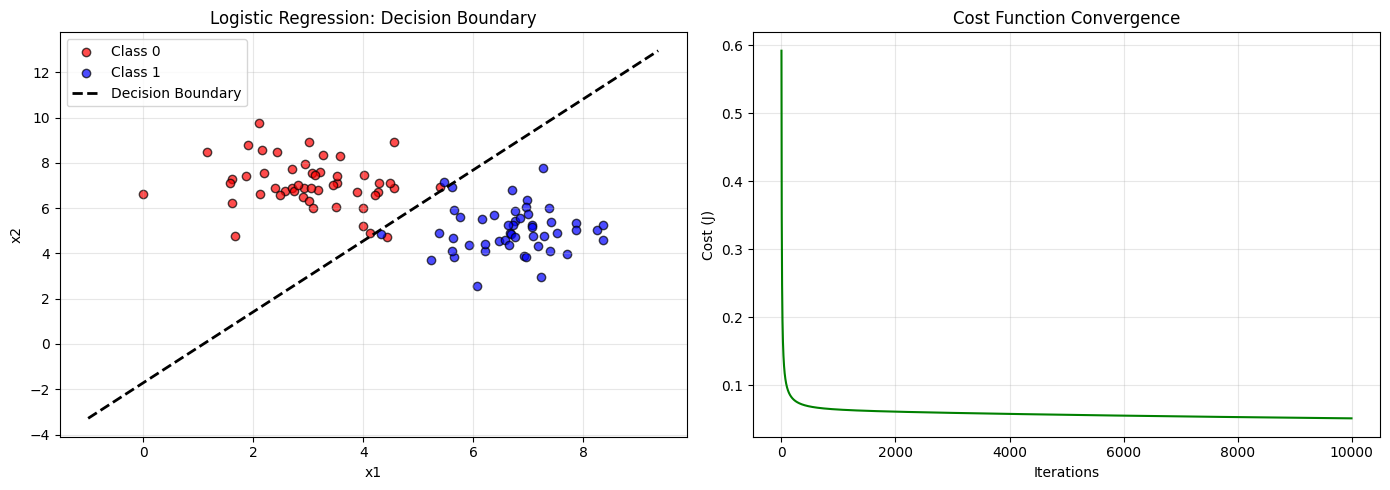

In [31]:
#7. Visualization
plt.figure(figsize=(14, 5))

# --- Plot 1: Data + Decision Boundary ---
plt.subplot(1, 2, 1)
# FIX: Use y directly since it is now 1D
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='red', label='Class 0', alpha=0.7, edgecolors='k')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='blue', label='Class 1', alpha=0.7, edgecolors='k')

# Decision boundary equation: θ0 + θ1*x1 + θ2*x2 = 0
# Solve for x2: x2 = -(θ0 + θ1*x1) / θ2
x1_vals = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
x2_vals = -(theta_optimized[0] + theta_optimized[1] * x1_vals) / theta_optimized[2]

plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label='Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression: Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Cost History ---
plt.subplot(1, 2, 2)
plt.plot(costs, color='green')
plt.xlabel('Iterations')
plt.ylabel('Cost (J)')
plt.title('Cost Function Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_result.png', dpi=300)
plt.show()

In [32]:
#8. Prediction function for new data
def predict_class(x1_new, x2_new, theta):
    """Predict class for new input values"""
    x_new = np.array([1, x1_new, x2_new]).reshape(3, 1)
    prob = sigmoid(x_new.T @ theta)[0][0]
    return 1 if prob >= 0.5 else 0, prob

# Example usage:
test_x1, test_x2 = 5.0, 5.0
pred_class, pred_prob = predict_class(test_x1, test_x2, theta_optimized)
print(f"\n🔍 Example Prediction: x1={test_x1}, x2={test_x2}")
print(f"   Probability of Class 1: {pred_prob:.4f}")
print(f"   Predicted Class: {pred_class}")


🔍 Example Prediction: x1=5.0, x2=5.0
   Probability of Class 1: 0.9127
   Predicted Class: 1
